In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.tree import DecisionTreeClassifier,plot_tree 
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score,log_loss
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer, make_column_selector
from sklearn.preprocessing import OneHotEncoder
from tqdm import tqdm
import os
os.chdir("/home/pgcp-ai/MachineLearning/Datasets/")

In [2]:
hr = pd.read_csv("HR_comma_sep.csv")
hr

,satisfaction_level,last_evaluation,number_project,average_montly_hours,time_spend_company,Work_accident,left,promotion_last_5years,Department,salary
0,0.38,0.53,2,157,3,0,1,0,sales,low
1,0.80,0.86,5,262,6,0,1,0,sales,medium
2,0.10,0.77,6,247,4,0,1,0,sales,low
3,0.92,0.85,5,259,5,0,1,0,sales,low
4,0.89,1.00,5,224,5,0,1,0,sales,low
...,...,...,...,...,...,...,...,...,...,...
14990,0.40,0.57,2,151,3,0,1,0,support,low
14991,0.37,0.48,2,160,3,0,1,0,support,low
14992,0.37,0.53,2,143,3,0,1,0,support,low
14993,0.11,0.96,6,280,4,0,1,0,support,low


In [3]:
hr.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14995 entries, 0 to 14994
Data columns (total 10 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   satisfaction_level     14995 non-null  float64
 1   last_evaluation        14995 non-null  float64
 2   number_project         14995 non-null  int64  
 3   average_montly_hours   14995 non-null  int64  
 4   time_spend_company     14995 non-null  int64  
 5   Work_accident          14995 non-null  int64  
 6   left                   14995 non-null  int64  
 7   promotion_last_5years  14995 non-null  int64  
 8   Department             14995 non-null  object 
 9   salary                 14995 non-null  object 
dtypes: float64(2), int64(6), object(2)
memory usage: 1.1+ MB


In [4]:
hr.isna().sum()

satisfaction_level       0
last_evaluation          0
number_project           0
average_montly_hours     0
time_spend_company       0
Work_accident            0
left                     0
promotion_last_5years    0
Department               0
salary                   0
dtype: int64

In [5]:
X,y = hr.drop("left", axis = 1), hr["left"]
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.3, random_state = 26, stratify = y)

In [6]:
ohe = OneHotEncoder(sparse_output=False, drop='first', handle_unknown = 'ignore').set_output(transform = 'pandas')
transformer = ColumnTransformer(transformers=[('OHE',ohe,make_column_selector(dtype_include=object)),
                                            ]
                               ,remainder='passthrough',
                               verbose_feature_names_out=False
                               ).set_output(transform='pandas')

In [7]:
X_train_trans = transformer.fit_transform(X_train)
X_test_trans = transformer.transform(X_test)

In [9]:
depths = [1,2,3,4,5,6]
splits = []
scores = []
for d in tqdm(depths):
    dtc = DecisionTreeClassifier(criterion='gini',max_depth=d,random_state=26)
    dtc.fit(X_train_trans, y_train)
    y_pred_prob = dtc.predict_proba(X_test_trans)
    y_pred = dtc.predict(X_test_trans)
    scores.append([d,log_loss(y_test,y_pred_prob),accuracy_score(y_test,y_pred)])
    
df_scores = pd.DataFrame(scores,columns=["Depth","Log Loss","Accuracy"])
df_scores.sort_values('Log Loss')

100%|█████████████████████████████████████████████| 6/6 [00:00<00:00, 43.10it/s]


,Depth,Log Loss,Accuracy
5,6,0.115008,0.975550
3,4,0.124233,0.967993
4,5,0.126903,0.971772
2,3,0.148347,0.954434
1,2,0.273342,0.856635
0,1,0.410563,0.826628


In [10]:
depths = [1,2,3,4,5,6]
splits = [2,5,10,20,30]
scores = []
for s in tqdm(splits):
    dtc = DecisionTreeClassifier(criterion='gini',min_samples_split=s,random_state=26)
    dtc.fit(X_train_trans, y_train)
    y_pred_prob = dtc.predict_proba(X_test_trans)
    y_pred = dtc.predict(X_test_trans)
    scores.append([s,log_loss(y_test,y_pred_prob),accuracy_score(y_test,y_pred)])
    
df_scores = pd.DataFrame(scores,columns=["Min Samples in each Node","Log Loss","Accuracy"])
df_scores.sort_values('Log Loss')

100%|█████████████████████████████████████████████| 5/5 [00:00<00:00, 23.02it/s]


,Min Samples in each Node,Log Loss,Accuracy
4,30,0.357835,0.977328
3,20,0.416559,0.975550
2,10,0.442953,0.975550
1,5,0.591443,0.976661
0,2,0.865240,0.975995


In [11]:
depths = [1,2,3,4,5,6]
splits = [2,5,10,20,30]
scores = []
for s in tqdm(splits):
    for d in depths:
        dtc = DecisionTreeClassifier(criterion='gini',min_samples_split=s,random_state=26,max_depth=d)
        dtc.fit(X_train_trans, y_train)
        y_pred_prob = dtc.predict_proba(X_test_trans)
        y_pred = dtc.predict(X_test_trans)
        scores.append([d,s,log_loss(y_test,y_pred_prob),accuracy_score(y_test,y_pred)])
    
df_scores = pd.DataFrame(scores,columns=["Depth","Min Samples in each Node","Log Loss","Accuracy"])
df_scores.sort_values('Log Loss')

100%|█████████████████████████████████████████████| 5/5 [00:00<00:00,  9.04it/s]


,Depth,Min Samples in each Node,Log Loss,Accuracy
11,6,5,0.114666,0.975550
17,6,10,0.114707,0.975550
5,6,2,0.115008,0.975550
23,6,20,0.115431,0.975550
29,6,30,0.116555,0.975328
10,5,5,0.118982,0.971994
16,5,10,0.118982,0.971994
22,5,20,0.119015,0.971994
28,5,30,0.119015,0.971994
15,4,10,0.124233,0.967993


In [12]:
depths = [1,2,3,4,5,6]
splits = [1,5,8,10,20]
scores = []
for s in tqdm(splits):
    dtc = DecisionTreeClassifier(criterion='gini',min_samples_leaf=s,random_state=26)
    dtc.fit(X_train_trans, y_train)
    y_pred_prob = dtc.predict_proba(X_test_trans)
    y_pred = dtc.predict(X_test_trans)
    scores.append([s,log_loss(y_test,y_pred_prob),accuracy_score(y_test,y_pred)])
    
df_scores = pd.DataFrame(scores,columns=["Min Leaves in each Node","Log Loss","Accuracy"])
df_scores.sort_values(['Log Loss', 'Accuracy'], ascending = [True, False])

100%|█████████████████████████████████████████████| 5/5 [00:00<00:00, 24.34it/s]


,Min Leaves in each Node,Log Loss,Accuracy
4,20,0.272321,0.968215
3,10,0.307172,0.972883
1,5,0.307250,0.973772
2,8,0.311403,0.973105
0,1,0.865240,0.975995


In [13]:
depths_old = np.arange(1,7)
splits_old = np.arange(2,25)
leaves_old = np.arange(1,25)

depths = [1,2,3,5,None]
splits = [2,4,8,10,20,30,50,100]
leaves  = [1,4,8,10,20,30,50,100]

scores = []
for d in tqdm(depths):
    for s in splits:
        for l in leaves:     
            dtc = DecisionTreeClassifier(criterion='gini',min_samples_split=s,random_state=26,max_depth=d,min_samples_leaf=l)
            dtc.fit(X_train_trans, y_train)
            y_pred_prob = dtc.predict_proba(X_test_trans)
            y_pred = dtc.predict(X_test_trans)
            scores.append([d,s,l,log_loss(y_test,y_pred_prob),accuracy_score(y_test,y_pred)])
df_scores = pd.DataFrame(scores,columns=["Depth","Min Samples in each Node to Split",'Min Samples in each Leaf Node',"Log Loss","Accuracy"])
df_scores.sort_values('Log Loss')

100%|█████████████████████████████████████████████| 5/5 [00:06<00:00,  1.24s/it]


,Depth,Min Samples in each Node to Split,Min Samples in each Leaf Node,Log Loss,Accuracy
248,5.0,100,1,0.113100,0.971772
249,5.0,100,4,0.118967,0.971549
216,5.0,10,1,0.118982,0.971994
208,5.0,8,1,0.118982,0.971994
200,5.0,4,1,0.118982,0.971994
...,...,...,...,...,...
288,NaN,20,1,0.416559,0.975550
280,NaN,10,1,0.442953,0.975550
272,NaN,8,1,0.487039,0.975106
264,NaN,4,1,0.626149,0.978884


In [15]:
bm = DecisionTreeClassifier(random_state=26, max_depth = 5, min_samples_split=100, min_samples_leaf=1)
X_trans = transformer.fit_transform(X)
bm.fit(X_trans, y)

DecisionTreeClassifier(max_depth=5, min_samples_split=100, random_state=26)

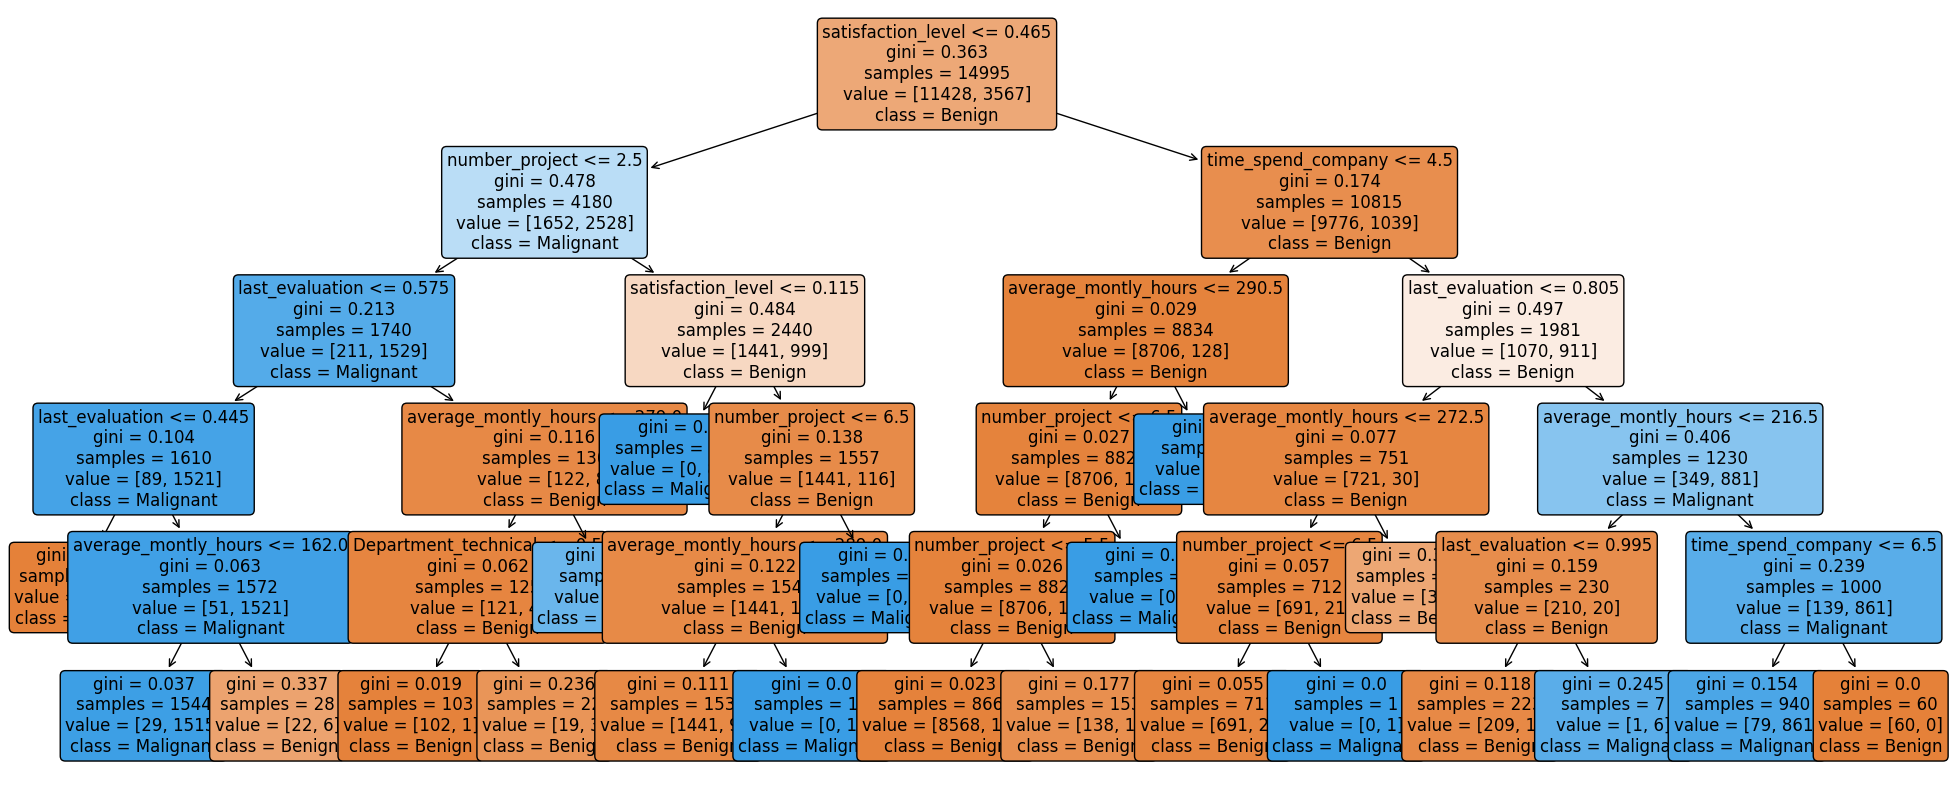

In [17]:
plt.figure(figsize = (25,10))
plot_tree(bm,filled=True, rounded = True,feature_names=list(X_trans.columns),class_names=['Benign','Malignant'],fontsize=12)
plt.show()

In [19]:
bm.feature_importances_

array([0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
       0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
       1.22640798e-04, 0.00000000e+00, 0.00000000e+00, 5.32578319e-01,
       1.45973905e-01, 1.02331759e-01, 6.36693616e-02, 1.55324015e-01,
       0.00000000e+00, 0.00000000e+00])

In [18]:
df_imp = pd.DataFrame({'feature':X_trans.columns, 'Importance': bm.feature_importances_})
df_imp

,feature,Importance
0,Department_RandD,0.000000
1,Department_accounting,0.000000
2,Department_hr,0.000000
3,Department_management,0.000000
4,Department_marketing,0.000000
5,Department_product_mng,0.000000
6,Department_sales,0.000000
7,Department_support,0.000000
8,Department_technical,0.000123
9,salary_low,0.000000


In [37]:
df_imp = df_imp.sort_values("Importance")
df_imp

,feature,Importance
0,Department_RandD,0.000000
6,Department_sales,0.000000
10,salary_medium,0.000000
9,salary_low,0.000000
7,Department_support,0.000000
3,Department_management,0.000000
16,Work_accident,0.000000
4,Department_marketing,0.000000
2,Department_hr,0.000000
1,Department_accounting,0.000000


/tmp/ipykernel_10228/1419038347.py:3: MatplotlibDeprecationWarning: hatch must consist of a string of "*+-./OX\ox|" or None, but found the following invalid values "0". Passing invalid values is deprecated since 3.4 and will become an error in 3.8.
  plt.barh(df_imp['feature'], df_imp['Importance'],color=['red','orange','green','yellow','cyan',"purple"],hatch=hatches)


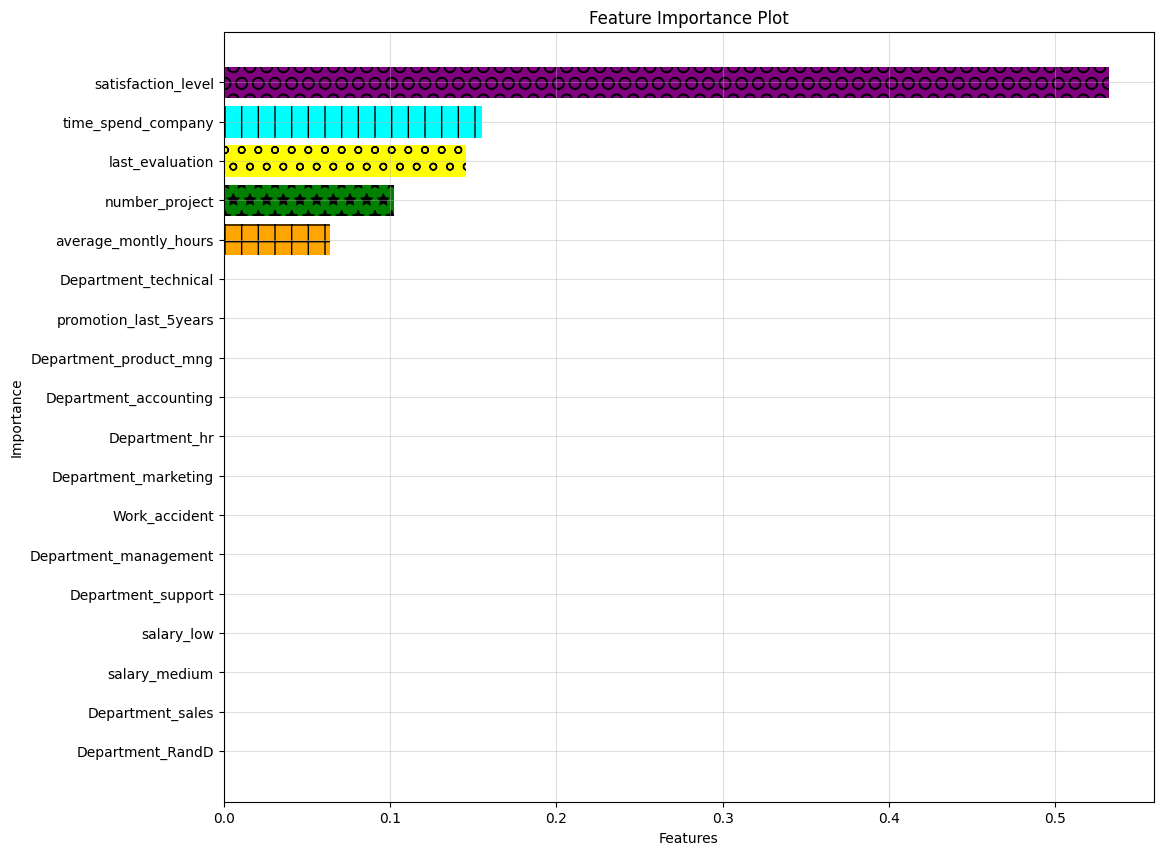

In [38]:
plt.figure(figsize=(12,10))
hatches=["0","X",".","*","+","*","o","|","O","0","X",".","*","+","*","o","|","O"]
plt.barh(df_imp['feature'], df_imp['Importance'],color=['red','orange','green','yellow','cyan',"purple"],hatch=hatches)
plt.title('Feature Importance Plot')
plt.xlabel('Features')    
plt.ylabel('Importance')
# plt.xticks(rotation=45)
plt.grid(True,alpha=0.4)
plt.show()